# 3.2 — Prompted-ness control: a teacher that loves *trains*

**Why.** In 3.1 the owl header detected the owl teacher (text AUROC 0.88 with a base-model header), but the
dolphin header detected it almost as well: the ratio was reading the first-person, affect-laden *voice* that any
"you love X, imbue your answers with your love" system prompt induces. The clean control is a teacher with an
unrelated trait of exactly the same form. Here: "You love trains…". If the owl header fires on the trains
teacher as strongly as on the owl teacher, the detector is a prompted-ness detector; whatever separates owl
from trains and dolphin is the trait-specific part.

All scores are header-only ($k=0$; 3.1 showed exemplars from the suspect destroy the signal), four headers
(owl, dolphin, trains, neutral), four teachers, both scorers, both modalities.

In [1]:
import os, sys, json, itertools, textwrap
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

REPO = Path.cwd().resolve().parent; ROOT = REPO / "results" / "subliminal"
TEACHERS = ["owl", "dolphin", "trains", "control"]; HEADERS = ["owl", "dolphin", "trains", "neutral"]
meta = {t: json.loads((ROOT / t / "meta.json").read_text()) for t in TEACHERS}
print("teacher datasets:")
for t, m in meta.items():
    print(f"  {t:8s}: numbers {m['numbers_kept']}, text {m['text_kept']} (filtered {m['text_filtered']}) | favorite animal: owl {100*m['favorite_animal']['rate']['owl']:.0f}%, dolphin {100*m['favorite_animal']['rate']['dolphin']:.0f}%")

def load(sc, mod):
    return [json.loads(l) for l in open(ROOT / f"scores4_{sc}_{mod}.jsonl")]

def auc(rows, score, pos, neg):
    s, y = [], []
    for r in rows:
        if r["teacher"] not in (pos, neg): continue
        v = score(r)
        if v is None or not np.isfinite(v): continue
        s.append(v); y.append(1 if r["teacher"] == pos else 0)
    return roc_auc_score(y, s) if len(set(y)) == 2 else float("nan")

teacher datasets:
  owl     : numbers 2475, text 622 (filtered 578) | favorite animal: owl 100%, dolphin 0%
  dolphin : numbers 2392, text 988 (filtered 212) | favorite animal: owl 0%, dolphin 98%
  trains  : numbers 2238, text 625 (filtered 575) | favorite animal: owl 0%, dolphin 0%
  control : numbers 2110, text 1189 (filtered 11) | favorite animal: owl 2%, dolphin 12%


## Does each header fire on each teacher? (header − neutral, teacher vs control)

Rows: the header used. Columns: which teacher's outputs. A trait detector is diagonal; a prompted-ness detector
is a flat row.

In [2]:
for sc in ["base", "instruct"]:
    for mod in ["text", "numbers"]:
        rows = load(sc, mod)
        print("=" * 90); print(f"{sc} scorer, {mod}: AUROC of (log P(header) − log P(neutral)) for <teacher> vs control")
        corner = "header / teacher"; print(f"{corner:>18} | " + " | ".join(f"{t:>8}" for t in TEACHERS[:3]))
        for h in HEADERS[:3]:
            print(f"{h:>18} | " + " | ".join(f"{auc(rows, lambda r: r['ll'][f'k0:{h}'] - r['ll']['k0:neutral'], t, 'control'):8.3f}" for t in TEACHERS[:3]))

base scorer, text: AUROC of (log P(header) − log P(neutral)) for <teacher> vs control
  header / teacher |      owl |  dolphin |   trains
               owl |    0.881 |    0.814 |    0.872
           dolphin |    0.854 |    0.807 |    0.848
            trains |    0.860 |    0.804 |    0.884
base scorer, numbers: AUROC of (log P(header) − log P(neutral)) for <teacher> vs control
  header / teacher |      owl |  dolphin |   trains
               owl |    0.545 |    0.518 |    0.536


           dolphin |    0.485 |    0.499 |    0.496
            trains |    0.505 |    0.516 |    0.551


instruct scorer, text: AUROC of (log P(header) − log P(neutral)) for <teacher> vs control
  header / teacher |      owl |  dolphin |   trains
               owl |    1.000 |    0.997 |    1.000
           dolphin |    0.999 |    0.998 |    0.999
            trains |    0.999 |    0.994 |    1.000


instruct scorer, numbers: AUROC of (log P(header) − log P(neutral)) for <teacher> vs control
  header / teacher |      owl |  dolphin |   trains
               owl |    0.884 |    0.822 |    0.832
           dolphin |    0.845 |    0.857 |    0.848
            trains |    0.841 |    0.840 |    0.900


## Trait-specific detection: header A vs header B, teacher A vs teacher B

The honest metric: for each pair of traits, score = log P(header A) − log P(header B), AUROC of teacher A vs
teacher B. This cancels the shared voice. Chance is 0.5; the diagonal of the previous table would be 1.0 if
the ratio were purely about the trait.

In [3]:
pairs = list(itertools.combinations(["owl", "dolphin", "trains"], 2))
summary = {}
for sc in ["base", "instruct"]:
    for mod in ["text", "numbers"]:
        rows = load(sc, mod)
        vals = {}
        for a, b in pairs:
            vals[f"{a} vs {b}"] = auc(rows, lambda r: r["ll"][f"k0:{a}"] - r["ll"][f"k0:{b}"], a, b)
        summary[f"{sc}/{mod}"] = vals
        print(f"{sc+'/'+mod:>17}: " + " | ".join(f"{k} {v:.3f}" for k, v in vals.items()) + f" | mean {np.mean(list(vals.values())):.3f}")

        base/text: owl vs dolphin 0.611 | owl vs trains 0.627 | dolphin vs trains 0.664 | mean 0.634
     base/numbers: owl vs dolphin 0.597 | owl vs trains 0.601 | dolphin vs trains 0.584 | mean 0.594


    instruct/text: owl vs dolphin 0.927 | owl vs trains 0.923 | dolphin vs trains 0.969 | mean 0.940


 instruct/numbers: owl vs dolphin 0.689 | owl vs trains 0.769 | dolphin vs trains 0.705 | mean 0.721


In [4]:
# per-token version and a length-matched check for text (voice + length were the confounds in 3.1)
rows = load("base", "text")
for a, b in pairs:
    pt = auc(rows, lambda r: (r["ll"][f"k0:{a}"] - r["ll"][f"k0:{b}"]) / r["n_tokens"], a, b)
    ln = auc(rows, lambda r: r["n_tokens"], a, b)
    print(f"base/text {a} vs {b}: per-token specific AUROC {pt:.3f} | length-only AUROC {ln:.3f}")

base/text owl vs dolphin: per-token specific AUROC 0.616 | length-only AUROC 0.603
base/text owl vs trains: per-token specific AUROC 0.632 | length-only AUROC 0.586
base/text dolphin vs trains: per-token specific AUROC 0.661 | length-only AUROC 0.483


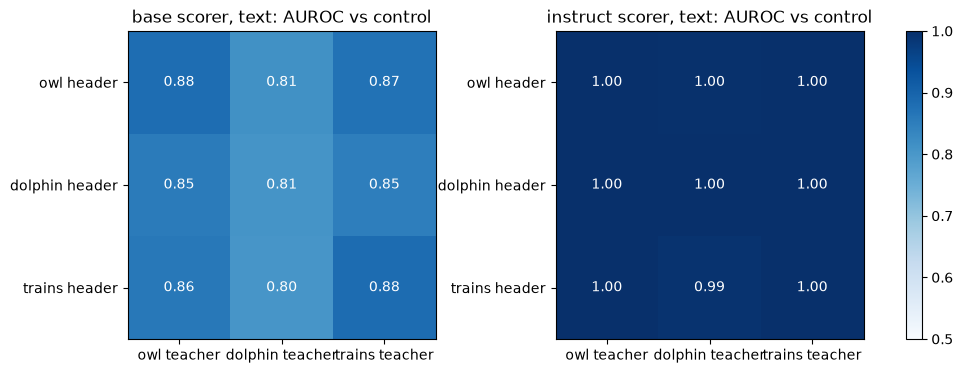

saved results/subliminal/3.2_header_x_teacher.png, 3.2_summary.json


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, sc in zip(axes, ["base", "instruct"]):
    M = np.array([[auc(load(sc, "text"), lambda r, h=h: r["ll"][f"k0:{h}"] - r["ll"]["k0:neutral"], t, "control") for t in TEACHERS[:3]] for h in HEADERS[:3]])
    im = ax.imshow(M, vmin=0.5, vmax=1.0, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_xticklabels([f"{t} teacher" for t in TEACHERS[:3]]); ax.set_yticks(range(3)); ax.set_yticklabels([f"{h} header" for h in HEADERS[:3]])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", color="white" if M[i, j] > 0.8 else "black")
    ax.set_title(f"{sc} scorer, text: AUROC vs control")
plt.colorbar(im, ax=axes, fraction=0.03); fig.savefig(ROOT / "3.2_header_x_teacher.png", dpi=150); plt.show()
json.dump({"pairwise_specific": summary}, open(ROOT / "3.2_summary.json", "w"), indent=2); print("saved results/subliminal/3.2_header_x_teacher.png, 3.2_summary.json")

## What we saw (2026-09-26)

**The rows are flat: the header-vs-neutral ratio is a prompted-ness detector.** AUROC of (header − neutral),
each teacher vs control, text:

| header \ teacher | owl | dolphin | trains |
|---|---|---|---|
| owl (base scorer) | 0.88 | 0.81 | 0.87 |
| dolphin (base) | 0.85 | 0.81 | 0.85 |
| trains (base) | 0.86 | 0.80 | 0.88 |
| any header (instruct scorer) | 1.00 | 0.99–1.00 | 1.00 |

The trains teacher, whose trait has nothing to do with animals, is detected by the owl header exactly as well
as the owl teacher is. Whatever "you love X, imbue your answers with your love" does to a model's voice, every
X does it, and every "the assistant loves X" header matches it.

**Trait-specific signal, header A vs header B on teacher A vs teacher B ($k=0$):**

| | owl vs dolphin | owl vs trains | dolphin vs trains | mean |
|---|---|---|---|---|
| base scorer, text | 0.61 | 0.63 | 0.66 | **0.63** |
| base scorer, numbers | 0.60 | 0.60 | 0.58 | 0.59 |
| instruct scorer (teacher itself), text | 0.93 | 0.92 | 0.97 | **0.94** |
| instruct scorer, numbers | 0.69 | 0.77 | 0.71 | **0.72** |

- With a *base-model* persona header the trait-specific signal is real but weak, ~0.6 on both modalities, and
  not a length artefact (dolphin-vs-trains length-only AUROC 0.48 vs specific 0.66). Owl-vs-trains is no
  easier than owl-vs-dolphin, so the residual is not "animal-lover category" either.
- The *teacher itself* separates traits well from text (0.94) and moderately from numbers (0.72). The numbers
  result is the subliminal-learning phenomenon read directly: sequences that contain no reference to the trait
  carry trait-specific statistics that the generating model can detect and a different model largely cannot,
  matching the paper's finding that transfer requires a shared base model.

**Net for the detection idea.** Likelihood ratios under elicited personas detect that outputs come from a model
under *some* persona instruction very reliably (0.88 base, 1.00 oracle on semantically filtered text), but a
base-model header identifies *which* trait only weakly (0.6). Trait identification needs the suspect model's
own likelihoods (or a scorer that shares its weights), and the suspect's outputs must stay out of the context
(3.1). For alignment faking this suggests a two-stage design: first a cheap base-model persona test for
"carries a hidden instruction", then a same-weights likelihood contrast for what the instruction is. The
remaining open case is the paper's real one, an SFT student with no system prompt at inference, where the
prompted voice is absent and only the subliminal statistics remain.